the below changes the wavelength limits to look at the H2O feature with the base logX mixing ratio

A_H = 5.270018188320329
A_H = 5.277270685978629
A_H = 5.280786331497205
A_H = 5.2814310389292745
A_H = 5.2760648484882
A_H = 5.25874966908216
A_H = 5.16895381839311
A_H = 5.066075469809381
A_H = 4.945728106415747
A_H = 4.820409162867427
A_H = 4.699534880388914
A_H = 4.583686623062246
A_H = 4.477645572152292
A_H = 4.37970770887617
A_H = 4.2952989307535665
A_H = 4.219114647114477
A_H = 4.166306586756276
A_H = 4.1194042492500484


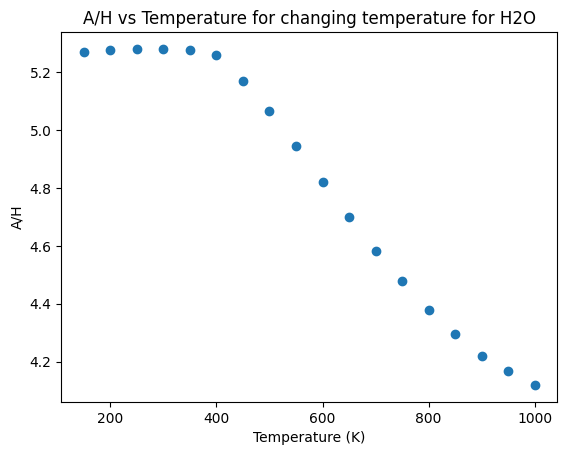

In [13]:
import numpy as np
import os
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import csv
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

A_H_Array = []
feature_height_ppm_Array = []
scale_height_array = []

with open("/Users/evely/Group-Studies---Exoplanets/Code/Data/GJ 1214 b change in temp.csv", newline="") as PlanetaryParametersFile:   
	reader = csv.reader(PlanetaryParametersFile)
	header = next(reader)
	tsm_idx = header.index("pl_tsm")
	temp_idx = header.index("pl_Teq")
	data = []
	planetNames = []
	tsm_values = []
	temp_values = []
	for row in reader:
		row = [item.strip() for item in row]
		if len(row) == 0:
			continue
		name, *nums = row
		conv = [float(item) if item != "" else np.nan for item in nums]
		data.append(conv)
		planetNames.append(name)
		tsm = float(nums[tsm_idx - 1]) if nums[tsm_idx - 1] != "" else np.nan
		tsm_values.append(tsm)
		temp = float(nums[temp_idx - 1]) if nums[temp_idx - 1] != "" else np.nan
		temp_values.append(temp)
	planetaryParameters = np.array(data, dtype=float)
	
rowCount= 0
while rowCount < len(planetaryParameters):
	PName = planetNames[rowCount]                                   ## planet name   
	#print(f"---Analysing Planet: {PName} ----")
	#print(f"Star Manitude: {planetaryParameters[rowCount][20]}")

    ## CHANGE INDEXES IF NEED BE ##
	
	Rp = planetaryParameters[rowCount][3]                           ## planet radius in units of Earth radii
	Mp = planetaryParameters[rowCount][2]                           ## planet mass in units of Earth masses
	Tp = planetaryParameters[rowCount][39]                          ## planet temperature in K
	mu = 4.88                                                       ## mean molecular weight in atomic mass units
	Pcloud = 100
	Pref = 0.01                                                     ## pressure at top of cloud deck in bar  
	Rs = planetaryParameters[rowCount][14]                          ## stellar radius in units of Solar radii     
	Rp *= const.R_earth.value                                       ## Convert Rp from units of R_Earth to m
	Rs *= const.R_sun.value                                         ## Convert Rs from units of R_Sun to m
	Pcloud *= 1.0e5                                                 ## Convert Pcloud from bar to Pa
	Pref *= 1.0e5                                                   ## Convert Pref from bar to Pa
	mu *= sc.u                                                      ## Convert mu from atomic mass units to kg


	xsec_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
	lam_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
	P_h2o = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
	T_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

	# Read in CO2 cross section data
	xsec_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
	lam_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
	P_co2 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
	T_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

	# Read in CH4 cross section data
	xsec_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
	lam_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
	P_ch4 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
	T_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

	#read in CO cross section data
	xsec_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
	lam_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
	P_co = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
	T_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

	# H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
	xsec_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
	lam_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

	xsec_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
	lam_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')
	

	P = np.logspace(2.0,-9,200) * 1.0e5     # change from -9 to -10 was less than change from -9 to -8 so decided it was a nice middle ground

	T = Tp*np.ones_like(P)
	#print(T)
	n = P/(sc.k*T)
	#print(n)
	rho = mu*n
	gp = planetaryParameters[rowCount][37] / 100.0 # taking the grav values instead of calculating them
	r = np.zeros_like(P)
	g = np.zeros_like(P)
	i_Rp = np.argmin(np.abs(P-Pref))
	r[i_Rp] = Rp
	g[i_Rp] = gp

	# First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
	logX = dict()
	logX['h2o'] = -1.1
	logX['ch4'] = -1.74
	logX['co'] = -2.0
	logX['co2'] = -1.7
	#logX['nh3'] = -3.0

	## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
	mmw = dict()
	mmw['h2o'] = 18.0
	mmw['ch4'] = 16.0
	mmw['co'] = 28.0
	mmw['co2'] = 44.0
	mmw['h2'] = 2.0
	mmw['he'] = 4.0
	
	# Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
	# Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
	# Then X_H2 + X_He = 1 - X_rest

	X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
	X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
	X_He = 0.17 * X_H2

	# Now let's add H2 and He to the logX dictionary

	logX['h2'] = np.log10(X_H2)
	logX['he'] = np.log10(X_He)


		# With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
	mu = 0.0
	for mol in logX.keys():
		mu += np.power(10.0,logX[mol])*mmw[mol]
	mu *= sc.u # convert from amu to kg
	#print(f"The mean molecular weight is: {mu}")

	for i in range(i_Rp + 1, len(P)):
		g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
		r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

	for i in range(i_Rp-1, -1, -1):
		g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
		r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])




	xsec_dict = dict()
	lam_dict = dict()
	P_dict = dict()
	T_dict = dict()

	

	lam = np.linspace(0.61,5.0,5000)

	log_xsec_dict = dict()

	lamlam, PP = np.meshgrid(lam, P, indexing="ij")

	# ---- H2O ----
	interp_h2o = RegularGridInterpolator(
		(lam_h2o, P_h2o, T_h2o),
		xsec_h2o,
		method='linear', bounds_error=False,
		fill_value=None)
	log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))



	# ---- CO2 ----
	interp_co2 = RegularGridInterpolator(
		(lam_co2, P_co2, T_co2),
		xsec_co2,
		method='linear', bounds_error=False,
		fill_value=None
	)
	log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))


	# ---- CH4 ----
	interp_ch4 = RegularGridInterpolator(
		(lam_ch4, P_ch4, T_ch4),
		xsec_ch4,
		method='linear', bounds_error=False,
		fill_value=None
	)
	log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))
	

	interp_co = RegularGridInterpolator(
		(lam_co, P_co, T_co),
		xsec_co,
		method='linear', bounds_error=False,
		fill_value=None
	)
	log_xsec_dict['co'] = interp_co((lamlam, PP, T[0]))
	

	log_cia_dict = dict()
	log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
	log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

	sum_nsigma = np.zeros((len(lam), len(P)))
	for mol in log_xsec_dict.keys():
		sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

	sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
	sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

	integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
	integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

	exptau = np.zeros((len(P),len(lam)))
	transit_depth = np.zeros((len(lam)))

	# Compute the total optical depth at each impact parameter and wavelength #

	opacity = sum_nsigma #(kappa+sigma)
	# For each layer of atmosphere

	for i in range(len(r)-1):

		s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
		ds = s_tot[1:]-s_tot[:-1]

		tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

		# If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
		if P[i] > Pcloud:
			tau_tot += 1000.0

		# We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
		exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


	# Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
	for i in range(len(r)-1):

		# Rays travelling through atmosphere above Rp
		if (r[i] >= Rp):
			integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

		# Rays travelling through atmosphere below Rp
		if (r[i] < Rp):
			integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

	# Compute effective transit depth (transmission spectrum) #
	transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)




	lam_data = lam
	depth_data = transit_depth

	# 2. Find Left Trough (4-4.3 um)
	left_mask = (lam_data >= 1.2) & (lam_data <= 1.35)   #H2O feature
	#left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
	# Extract values in that window
	left_depth_values = depth_data[left_mask]
	left_lam_values = lam_data[left_mask]
	# Take averages
	left_val = np.mean(left_depth_values)
	left_lam_target = np.mean(left_lam_values)

	# 3. Find Right Trough (4.6-4.8 um)
	right_mask = (lam_data >= 1.45) & (lam_data <= 1.6)   #H2O feature
	#right_mask = (lam_data >= 4.6) & (lam_data <= 4.8)   # CO2 feature

	# 4. Identify the Peak region between those two troughs
	peak_mask = (lam_data >= 1.38) & (lam_data <= 1.42)   #H2O feature
    #peak_mask = (lam_data >= 4.25) & (lam_data <= 4.28)   # CO2 feature
	# Extract values in that window
	peak_region_depths = depth_data[peak_mask]
	peak_x_values = lam_data[peak_mask]

	# 5. Calculate Height and the Scatter Error
	peak_val = np.mean(peak_region_depths)
	peak_x_value = np.mean(peak_x_values)
	feature_height_ratio = (peak_val - left_val)
	feature_height_ppm = (peak_val - left_val) * 1e6
	feature_height_ppm_Array.append(feature_height_ppm)


	# The "Error" is the standard deviation of the points in the peak region
	# This represents the local variation/noise in your model
	peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6


	# print(f"--- {PName} ---")
	# print(f"Feature Height: {feature_height_ppm:.2f} ppm")
	# print(peak_x_value)

	mu = mu/sc.u # convert back from kg to amu for scale height calculation
	#print(f"The mean molecular weight is: {mu}")
	scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)
	scale_height_array.append(scale_height)

	A_H = feature_height_ratio * (Rs ** 2) / (2*scale_height*Rp)
	A_H_Array.append(A_H)
	print('A_H =', A_H)

	rowCount += 1
	
plt.scatter(temp_values, A_H_Array, marker='o')
plt.xlabel('Temperature (K)')
plt.ylabel('A/H')   
plt.title('A/H vs Temperature for changing temperature for H2O')
plt.show()

A_H = 1.4135416040637774
A_H = 1.5295770188088587
A_H = 1.645596433389621
A_H = 1.7696573766271722
A_H = 1.9066384291971947
A_H = 2.057189715666166
A_H = 2.150174678865144
A_H = 2.241670616850666
A_H = 2.2994848096627756
A_H = 2.3540307898001633
A_H = 2.3916844626619884
A_H = 2.428533646117042
A_H = 2.461772630270471
A_H = 2.495715760695987
A_H = 2.522591633518952
A_H = 2.5510190411050924
A_H = 2.58495997400076
A_H = 2.6204129460551804


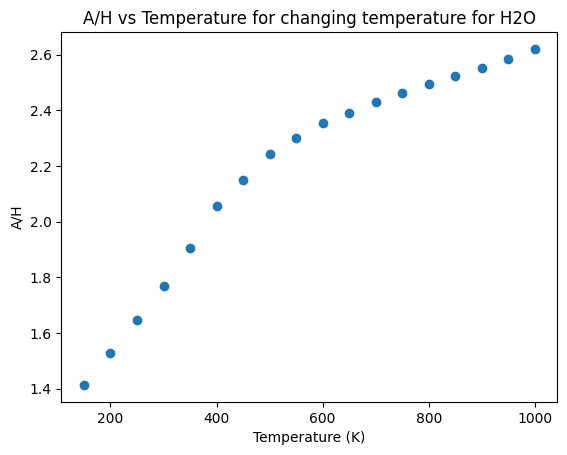

In [8]:
import numpy as np
import os
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import csv
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

A_H_Array = []
feature_height_ppm_Array = []
scale_height_array = []

with open("/Users/evely/Group-Studies---Exoplanets/Code/Data/GJ 1214 b change in temp.csv", newline="") as PlanetaryParametersFile:   
	reader = csv.reader(PlanetaryParametersFile)
	header = next(reader)
	tsm_idx = header.index("pl_tsm")
	temp_idx = header.index("pl_Teq")
	data = []
	planetNames = []
	tsm_values = []
	temp_values = []
	for row in reader:
		row = [item.strip() for item in row]
		if len(row) == 0:
			continue
		name, *nums = row
		conv = [float(item) if item != "" else np.nan for item in nums]
		data.append(conv)
		planetNames.append(name)
		tsm = float(nums[tsm_idx - 1]) if nums[tsm_idx - 1] != "" else np.nan
		tsm_values.append(tsm)
		temp = float(nums[temp_idx - 1]) if nums[temp_idx - 1] != "" else np.nan
		temp_values.append(temp)
	planetaryParameters = np.array(data, dtype=float)
	
rowCount= 0
while rowCount < len(planetaryParameters):
	PName = planetNames[rowCount]                                   ## planet name   
	#print(f"---Analysing Planet: {PName} ----")
	#print(f"Star Manitude: {planetaryParameters[rowCount][20]}")

    ## CHANGE INDEXES IF NEED BE ##
	
	Rp = planetaryParameters[rowCount][3]                           ## planet radius in units of Earth radii
	Mp = planetaryParameters[rowCount][2]                           ## planet mass in units of Earth masses
	Tp = planetaryParameters[rowCount][39]                          ## planet temperature in K
	mu = 4.88                                                       ## mean molecular weight in atomic mass units
	Pcloud = 100
	Pref = 0.01                                                     ## pressure at top of cloud deck in bar  
	Rs = planetaryParameters[rowCount][14]                          ## stellar radius in units of Solar radii     
	Rp *= const.R_earth.value                                       ## Convert Rp from units of R_Earth to m
	Rs *= const.R_sun.value                                         ## Convert Rs from units of R_Sun to m
	Pcloud *= 1.0e5                                                 ## Convert Pcloud from bar to Pa
	Pref *= 1.0e5                                                   ## Convert Pref from bar to Pa
	mu *= sc.u                                                      ## Convert mu from atomic mass units to kg


	xsec_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
	lam_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
	P_h2o = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
	T_h2o = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

	# Read in CO2 cross section data
	xsec_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
	lam_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
	P_co2 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
	T_co2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

	# Read in CH4 cross section data
	xsec_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
	lam_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
	P_ch4 = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
	T_ch4 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

	#read in CO cross section data
	xsec_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
	lam_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
	P_co = np.power(10.0,np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
	T_co = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

	# H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
	xsec_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
	lam_h2h2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

	xsec_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
	lam_heh2 = np.load('/Users/evely/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')
	

	P = np.logspace(2.0,-9,200) * 1.0e5     # change from -9 to -10 was less than change from -9 to -8 so decided it was a nice middle ground

	T = Tp*np.ones_like(P)
	#print(T)
	n = P/(sc.k*T)
	#print(n)
	rho = mu*n
	gp = planetaryParameters[rowCount][37] / 100.0 # taking the grav values instead of calculating them
	r = np.zeros_like(P)
	g = np.zeros_like(P)
	i_Rp = np.argmin(np.abs(P-Pref))
	r[i_Rp] = Rp
	g[i_Rp] = gp

	# First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
	logX = dict()
	logX['h2o'] = -4.1
	logX['ch4'] = -4.74
	logX['co'] = -5.0
	logX['co2'] = -4.7

	## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
	mmw = dict()
	mmw['h2o'] = 18.0
	mmw['ch4'] = 16.0
	mmw['co'] = 28.0
	mmw['co2'] = 44.0
	mmw['h2'] = 2.0
	mmw['he'] = 4.0
	
	# Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
	# Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
	# Then X_H2 + X_He = 1 - X_rest

	X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
	X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
	X_He = 0.17 * X_H2

	# Now let's add H2 and He to the logX dictionary

	logX['h2'] = np.log10(X_H2)
	logX['he'] = np.log10(X_He)


		# With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
	mu = 0.0
	for mol in logX.keys():
		mu += np.power(10.0,logX[mol])*mmw[mol]
	mu *= sc.u # convert from amu to kg
	#print(f"The mean molecular weight is: {mu}")

	for i in range(i_Rp + 1, len(P)):
		g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
		r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

	for i in range(i_Rp-1, -1, -1):
		g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
		r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])




	xsec_dict = dict()
	lam_dict = dict()
	P_dict = dict()
	T_dict = dict()

	

	lam = np.linspace(0.61,5.0,5000)

	log_xsec_dict = dict()

	lamlam, PP = np.meshgrid(lam, P, indexing="ij")

	# ---- H2O ----
	interp_h2o = RegularGridInterpolator(
		(lam_h2o, P_h2o, T_h2o),
		xsec_h2o,
		method='linear', bounds_error=False,
		fill_value=None)
	log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))



	# ---- CO2 ----
	interp_co2 = RegularGridInterpolator(
		(lam_co2, P_co2, T_co2),
		xsec_co2,
		method='linear', bounds_error=False,
		fill_value=None
	)
	log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))


	# ---- CH4 ----
	interp_ch4 = RegularGridInterpolator(
		(lam_ch4, P_ch4, T_ch4),
		xsec_ch4,
		method='linear', bounds_error=False,
		fill_value=None
	)
	log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))
	

	interp_co = RegularGridInterpolator(
		(lam_co, P_co, T_co),
		xsec_co,
		method='linear', bounds_error=False,
		fill_value=None
	)
	log_xsec_dict['co'] = interp_co((lamlam, PP, T[0]))
	

	log_cia_dict = dict()
	log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
	log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

	sum_nsigma = np.zeros((len(lam), len(P)))
	for mol in log_xsec_dict.keys():
		sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

	sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
	sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

	integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
	integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

	exptau = np.zeros((len(P),len(lam)))
	transit_depth = np.zeros((len(lam)))

	# Compute the total optical depth at each impact parameter and wavelength #

	opacity = sum_nsigma #(kappa+sigma)
	# For each layer of atmosphere

	for i in range(len(r)-1):

		s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
		ds = s_tot[1:]-s_tot[:-1]

		tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

		# If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
		if P[i] > Pcloud:
			tau_tot += 1000.0

		# We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
		exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


	# Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
	for i in range(len(r)-1):

		# Rays travelling through atmosphere above Rp
		if (r[i] >= Rp):
			integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

		# Rays travelling through atmosphere below Rp
		if (r[i] < Rp):
			integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

	# Compute effective transit depth (transmission spectrum) #
	transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)




	lam_data = lam
	depth_data = transit_depth

	# 2. Find Left Trough (4-4.3 um)
	left_mask = (lam_data >= 1.2) & (lam_data <= 1.35)   #H2O feature
	#left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
	# Extract values in that window
	left_depth_values = depth_data[left_mask]
	left_lam_values = lam_data[left_mask]
	# Take averages
	left_val = np.mean(left_depth_values)
	left_lam_target = np.mean(left_lam_values)

	# 3. Find Right Trough (4.6-4.8 um)
	right_mask = (lam_data >= 1.45) & (lam_data <= 1.6)   #H2O feature
	#right_mask = (lam_data >= 4.6) & (lam_data <= 4.8)   # CO2 feature

	# 4. Identify the Peak region between those two troughs
	peak_mask = (lam_data >= 1.38) & (lam_data <= 1.42)   #H2O feature
    #peak_mask = (lam_data >= 4.25) & (lam_data <= 4.28)   # CO2 feature
	# Extract values in that window
	peak_region_depths = depth_data[peak_mask]
	peak_x_values = lam_data[peak_mask]

	# 5. Calculate Height and the Scatter Error
	peak_val = np.mean(peak_region_depths)
	peak_x_value = np.mean(peak_x_values)
	feature_height_ratio = (peak_val - left_val)
	feature_height_ppm = (peak_val - left_val) * 1e6
	feature_height_ppm_Array.append(feature_height_ppm)


	# The "Error" is the standard deviation of the points in the peak region
	# This represents the local variation/noise in your model
	peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6


	# print(f"--- {PName} ---")
	# print(f"Feature Height: {feature_height_ppm:.2f} ppm")
	# print(peak_x_value)

	mu = mu/sc.u # convert back from kg to amu for scale height calculation
	#print(f"The mean molecular weight is: {mu}")
	scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)
	scale_height_array.append(scale_height)

	A_H = feature_height_ratio * (Rs ** 2) / (2*scale_height*Rp)
	A_H_Array.append(A_H)
	print('A_H =', A_H)

	rowCount += 1
	
plt.scatter(temp_values, A_H_Array, marker='o')
plt.xlabel('Temperature (K)')
plt.ylabel('A/H')   
plt.title('A/H vs Temperature for changing temperature for H2O')
plt.show()